# Titanic Survival Prediction
This notebook analyzes the Titanic dataset and applies multiple machine learning models to predict passenger survival.


In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## Load the Dataset

In [19]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Check Missing Values


In [33]:
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_df = missing_df[missing_df['Missing Values'] > 0]

print("=== Missing Values Summary ===")
print(missing_df)


=== Missing Values Summary ===
                  Column  Missing Values  Missing Percentage (%)
deck                deck             688               77.216611
embark_town  embark_town               2                0.224467


## Handle Missing Values

In [34]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)



numerical_cols = ['age', 'sibsp', 'parch', 'fare']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())


categorical_cols = ['embarked', 'sex', 'pclass']
for col in categorical_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [35]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['pclass'] = df['pclass'].astype(int)  

In [36]:
FEATURE_COLS = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
TARGET = 'survived'

X = df[FEATURE_COLS]
y = df[TARGET]

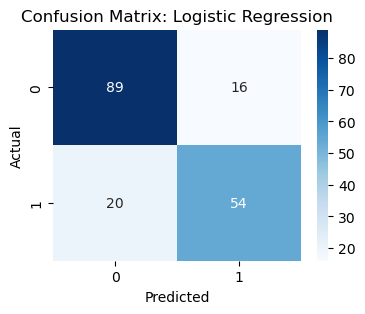

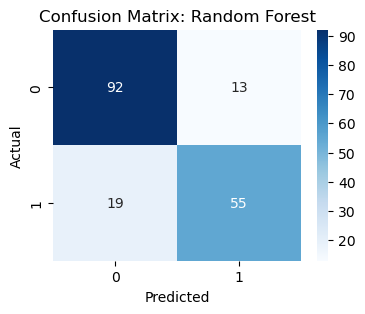

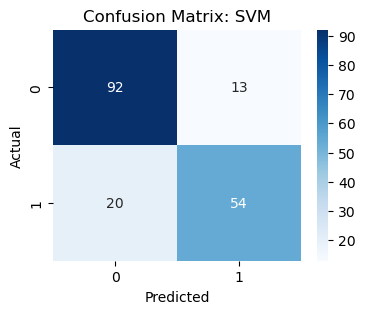

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


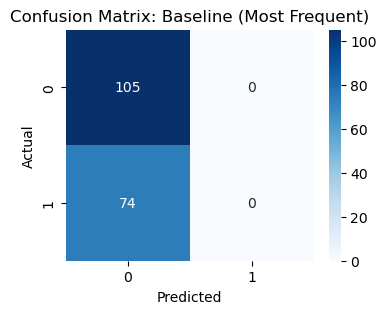

In [37]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Baseline (Most Frequent)": DummyClassifier(strategy="most_frequent")
}


# Model Training and Evaluation
results = {}

for name, model in models.items():
    
    numeric_features = ['age', 'sibsp', 'parch', 'fare']
    preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), numeric_features)],
        remainder='passthrough'  
    )
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
 
    pipeline.fit(X_train, y_train)
    
   
    y_pred = pipeline.predict(X_test)
    
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1}
  
  
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


The confusion matrices show that all machine learning models outperform the baseline model. Random Forest achieves the best balance between correctly predicting survivors and non-survivors, while the baseline model predicts only the majority class and fails to identify survivors.

## Model Performance Comparison

In [38]:
results_df = pd.DataFrame(results)
print("\n=== Model Performance Comparison ===")
print(results_df)


=== Model Performance Comparison ===
           Logistic Regression  Random Forest       SVM  \
Accuracy              0.798883       0.821229  0.815642   
Precision             0.771429       0.808824  0.805970   
Recall                0.729730       0.743243  0.729730   
F1 Score              0.750000       0.774648  0.765957   

           Baseline (Most Frequent)  
Accuracy                   0.586592  
Precision                  0.000000  
Recall                     0.000000  
F1 Score                   0.000000  


Random Forest achieved the best overall performance, Logistic Regression and SVM performed well, and the baseline model failed to predict survivors.